In [1]:
!pip install langchain==0.3.27

!pip install langchain-aws==0.2.34

!pip install langchain-community==0.3.31

!pip install langchain-core==0.3.79

!pip install langchain-experimental==0.3.4

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install langgraph==0.6.6

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
from langgraph.prebuilt import create_react_agent


In [2]:
import os
import json
from typing import List, Dict,TypedDict,Literal
# LangGraph imports
from langchain_core.tools import tool  # decorator to mark functions as tools
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
from langgraph.graph import StateGraph, END,START, MessagesState
from langgraph.prebuilt import create_react_agent, ToolNode
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage, ToolMessage
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableLambda, RunnableConfig


In [3]:
# os.environ["AWS_ACCESS_KEY_ID"]="AKIA...."
# os.environ["AWS_SECRET_ACCESS_KEY"]= "wQMJSFKPssS..."
# ---------------------------
# AWS Bedrock LLM Setup
# ---------------------------
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0" anthropic.claude-3-sonnet-20240229-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", 
                          region_name="us-east-1", 
                          temperature=0.5, 
                          max_tokens=1024)


In [4]:
@tool
def get_weather(city: str) -> str:
    """Return a one-line weather summary for 'city'."""
    # Replace this with real API call in production
    fake = {
        "Mysore": "23°C, partly cloudy",
        "New Delhi": "32°C, hot and humid",
        "Bangalore": "25°C, foggy"
    }
    return f"Weather in {city}: {fake.get(city, '20°C, clear skies')}"

@tool
def find_attractions(city: str) -> str:
    """Return a short list of top attractions for the city in JSON string form."""
    # Real implementation should call a places API and return structured data.
    attractions = {
        "Mysore": [
            {"name": "Mysore Palace", "type": "Hostorical", "visit_time_mins": 90},
            {"name": "Mysore Zoo", "type": "Zoology", "visit_time_mins": 120},
            {"name": "Sand Meuseum", "type": "museum", "visit_time_mins": 60},
        ],
        "Bangalore": [
            {"name": "LalBagh", "type": "entertainment", "visit_time_mins": 60},
            {"name": "Planitorium", "type": "Education", "visit_time_mins": 90},
        ]
    }
    res = attractions.get(city, [])
    return json.dumps(res)

@tool
def get_directions(origin: str, destination: str) -> str:
    """Return a short route summary."""
    # Replace with call to directions API for real routing information.
    return f"Route from {origin} to {destination}: Drive ~30 mins (20 km) via Main St."


tools = [get_weather, find_attractions, get_directions]


In [5]:
tools_by_name = {tool.name: tool for tool in tools}

model_with_tools = llm.bind_tools(tools)


In [6]:


def call_llm(state: MessagesState):
    # messages = state["messages"
    print("state['messages']:",state['messages'])
    return {"messages": [model_with_tools.invoke(state['messages'])]}

def call_tool(state: MessagesState):
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["environment", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "Action"
    return END


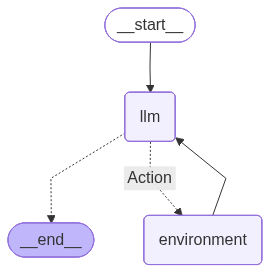

In [7]:
graph = StateGraph(MessagesState)
graph.add_node("llm", call_llm)
graph.add_node("environment", call_tool)
graph.add_edge(START, "llm")
graph.add_conditional_edges("llm",  should_continue, { "Action": "environment", END: END,},)
graph.add_edge("environment", "llm")
agent = graph.compile()
graph.compile()

In [105]:
messages = [
    SystemMessage(content="You are a helpful travel assistant. Your primary goal is to answer the user's request"
    "by *first* calling the available tools. **You must carefully extract all required "
    "arguments (like city name) from the user's message before calling a tool.** "
    "Then, use the tool results to provide a complete answer."
    "When satisfied with the tool response, output the final answer."),
    HumanMessage(content="I want to plan a travel to Mysore"),
]
from rich import print

for step in agent.stream({"messages": messages}, {"recursion_limit": 5}):
    print(step)
                        


state['messages']:
[
    SystemMessage(
        content="You are a helpful travel assistant. Your primary goal is to answer the user's requestby *first* 
calling the available tools. **You must carefully extract all required arguments (like city name) from the user's 
message before calling a tool.** Then, use the tool results to provide a complete answer.When satisfied with the 
tool response, output the final answer.",
        additional_kwargs={},
        response_metadata={},
        id='ab3cc84d-2ac4-457e-a92a-6babd8577539'
    ),
    HumanMessage(
        content='I want to plan a travel to Mysore',
        additional_kwargs={},
        response_metadata={},
        id='bb1529f2-7be3-4bb8-9ba2-19ccae27c03a'
    )
]

{
    'llm': {
        'messages': [
            AIMessage(
                content=[
                    {'type': 'text', 'text': 'I will find attractions in Mysore, and then write an answer.'},
                    {
                        'type': 'tool_use',
                        'name': 'find_attractions',
                        'input': {'city': 'Mysore'},
                        'id': 'tooluse_uWBBec7sRwiHPbnLbNX2IQ'
                    }
                ],
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '704c1dd0-04d6-472a-86e2-8e341e4af413',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 01 Dec 2025 06:41:23 GMT',
                            'content-type': 'application/json',
                            'content-length': '376',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '704c1dd0-04d6-472a-86e2-8e341e4af413'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'tool_use',
                    'metrics': {'latencyMs': [1734]},
                    'model_name': 'cohere.command-r-plus-v1:0'
                },
                id='run--278e6fe4-5828-4657-8dd0-16919d9591cc-0',
                tool_calls=[
                    {
                        'name': 'find_attractions',
                        'args': {'city': 'Mysore'},
                        'id': 'tooluse_uWBBec7sRwiHPbnLbNX2IQ',
                        'type': 'tool_call'
                    }
                ],
                usage_metadata={
                    'input_tokens': 128,
                    'output_tokens': 23,
                    'total_tokens': 151,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

{
    'environment': {
        'messages': [
            ToolMessage(
                content='[{"name": "Mysore Palace", "type": "Hostorical", "visit_time_mins": 90}, {"name": "Mysore 
Zoo", "type": "Zoology", "visit_time_mins": 120}, {"name": "Sand Meuseum", "type": "museum", "visit_time_mins": 
60}]',
                id='f3df075a-03c2-4590-ba28-45a925857cab',
                tool_call_id='tooluse_uWBBec7sRwiHPbnLbNX2IQ'
            )
        ]
    }
}

state['messages']:
[
    SystemMessage(
        content="You are a helpful travel assistant. Your primary goal is to answer the user's requestby *first* 
calling the available tools. **You must carefully extract all required arguments (like city name) from the user's 
message before calling a tool.** Then, use the tool results to provide a complete answer.When satisfied with the 
tool response, output the final answer.",
        additional_kwargs={},
        response_metadata={},
        id='ab3cc84d-2ac4-457e-a92a-6babd8577539'
    ),
    HumanMessage(
        content='I want to plan a travel to Mysore',
        additional_kwargs={},
        response_metadata={},
        id='bb1529f2-7be3-4bb8-9ba2-19ccae27c03a'
    ),
    AIMessage(
        content=[
            {'type': 'text', 'text': 'I will find attractions in Mysore, and then write an answer.'},
            {
                'type': 'tool_use',
                'name': 'find_attractions',
                'input': {'city': 'Mysore'},
                'id': 'tooluse_uWBBec7sRwiHPbnLbNX2IQ'
            }
        ],
        additional_kwargs={},
        response_metadata={
            'ResponseMetadata': {
                'RequestId': '704c1dd0-04d6-472a-86e2-8e341e4af413',
                'HTTPStatusCode': 200,
                'HTTPHeaders': {
                    'date': 'Mon, 01 Dec 2025 06:41:23 GMT',
                    'content-type': 'application/json',
                    'content-length': '376',
                    'connection': 'keep-alive',
                    'x-amzn-requestid': '704c1dd0-04d6-472a-86e2-8e341e4af413'
                },
                'RetryAttempts': 0
            },
            'stopReason': 'tool_use',
            'metrics': {'latencyMs': [1734]},
            'model_name': 'cohere.command-r-plus-v1:0'
        },
        id='run--278e6fe4-5828-4657-8dd0-16919d9591cc-0',
        tool_calls=[
            {
                'name': 'find_attractions',
                'args': {'city': 'Mysore'},
                'id': 'tooluse_uWBBec7sRwiHPbnLbNX2IQ',
                'type': 'tool_call'
            }
        ],
        usage_metadata={
            'input_tokens': 128,
            'output_tokens': 23,
            'total_tokens': 151,
            'input_token_details': {'cache_creation': 0, 'cache_read': 0}
        }
    ),
    ToolMessage(
        content='[{"name": "Mysore Palace", "type": "Hostorical", "visit_time_mins": 90}, {"name": "Mysore Zoo", 
"type": "Zoology", "visit_time_mins": 120}, {"name": "Sand Meuseum", "type": "museum", "visit_time_mins": 60}]',
        id='f3df075a-03c2-4590-ba28-45a925857cab',
        tool_call_id='tooluse_uWBBec7sRwiHPbnLbNX2IQ'
    )
]

{
    'llm': {
        'messages': [
            AIMessage(
                content='Mysore Palace, Mysore Zoo, and the Sand Museum are all attractions in Mysore.',
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '0ffd1642-81cc-41c8-b516-ecb100326002',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 01 Dec 2025 06:41:26 GMT',
                            'content-type': 'application/json',
                            'content-length': '282',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '0ffd1642-81cc-41c8-b516-ecb100326002'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'end_turn',
                    'metrics': {'latencyMs': [2600]},
                    'model_name': 'cohere.command-r-plus-v1:0'
                },
                id='run--e657ceba-22cc-4357-ac26-c10c2cd02698-0',
                usage_metadata={
                    'input_tokens': 231,
                    'output_tokens': 17,
                    'total_tokens': 248,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

In [9]:
step['llm']['messages'][0].content

'Mysore Palace, Mysore Zoo and the Sand Museum are some of the attractions in Mysore.'

## With Prebuilt Create React Agent

In [10]:
#  Define the System Prompt ---
system_prompt = (
    "You are a helpful assistant to suggest weather and attractions for a given place. "
    "You must use the available tools to gather necessary information before responding."
)

In [14]:
messages=[
    SystemMessage(content=system_prompt),
    HumanMessage(content="I want to visit Mysore for a trip")
]

In [18]:
prebuilt_agent= create_react_agent(
    model=llm,
    tools=tools,
)

In [19]:
from rich import print
for step in prebuilt_agent.stream({"messages": messages}, {"recursion_limit": 5}):
    print(step)

{
    'agent': {
        'messages': [
            AIMessage(
                content=[
                    {
                        'type': 'text',
                        'text': 'I will find the weather and attractions in Mysore, India, and then write an 
answer.'
                    },
                    {
                        'type': 'tool_use',
                        'name': 'get_weather',
                        'input': {'city': 'Mysore, India'},
                        'id': 'tooluse_zfnphplMTQCTOYamNdibzg'
                    },
                    {
                        'type': 'tool_use',
                        'name': 'find_attractions',
                        'input': {'city': 'Mysore'},
                        'id': 'tooluse_pagv7bidSeiom-Jp3vW-vQ'
                    }
                ],
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '8288d8fe-0812-457b-8c28-0a34f5aa0c78',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 01 Dec 2025 07:17:48 GMT',
                            'content-type': 'application/json',
                            'content-length': '511',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '8288d8fe-0812-457b-8c28-0a34f5aa0c78'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'tool_use',
                    'metrics': {'latencyMs': [2652]},
                    'model_name': 'cohere.command-r-plus-v1:0'
                },
                id='run--8f4427de-a8e1-447c-a1b6-a8949e236b54-0',
                tool_calls=[
                    {
                        'name': 'get_weather',
                        'args': {'city': 'Mysore, India'},
                        'id': 'tooluse_zfnphplMTQCTOYamNdibzg',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'find_attractions',
                        'args': {'city': 'Mysore'},
                        'id': 'tooluse_pagv7bidSeiom-Jp3vW-vQ',
                        'type': 'tool_call'
                    }
                ],
                usage_metadata={
                    'input_tokens': 83,
                    'output_tokens': 39,
                    'total_tokens': 122,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

{
    'tools': {
        'messages': [
            ToolMessage(
                content='Weather in Mysore, India: 20°C, clear skies',
                name='get_weather',
                tool_call_id='tooluse_zfnphplMTQCTOYamNdibzg'
            )
        ]
    }
}

{
    'tools': {
        'messages': [
            ToolMessage(
                content='[{"name": "Mysore Palace", "type": "Hostorical", "visit_time_mins": 90}, {"name": "Mysore 
Zoo", "type": "Zoology", "visit_time_mins": 120}, {"name": "Sand Meuseum", "type": "museum", "visit_time_mins": 
60}]',
                name='find_attractions',
                tool_call_id='tooluse_pagv7bidSeiom-Jp3vW-vQ'
            )
        ]
    }
}

{
    'agent': {
        'messages': [
            AIMessage(
                content='The weather in Mysore, India, is currently 20°C with clear skies. \n\nHere are some 
attractions you can visit:\n- Mysore Palace (90 minutes)\n- Mysore Zoo (120 minutes)\n- Sand Museum (60 minutes)',
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '0e0a2e15-9161-43f8-8929-ac96d58337a8',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 01 Dec 2025 07:17:53 GMT',
                            'content-type': 'application/json',
                            'content-length': '402',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '0e0a2e15-9161-43f8-8929-ac96d58337a8'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'end_turn',
                    'metrics': {'latencyMs': [4968]},
                    'model_name': 'cohere.command-r-plus-v1:0'
                },
                id='run--e5419b15-ce55-490b-9529-2a4daa420636-0',
                usage_metadata={
                    'input_tokens': 215,
                    'output_tokens': 56,
                    'total_tokens': 271,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

In [21]:
step['agent']['messages'][0].content

'The weather in Mysore, India, is currently 20°C with clear skies. \n\nHere are some attractions you can visit:\n- Mysore Palace (90 minutes)\n- Mysore Zoo (120 minutes)\n- Sand Museum (60 minutes)'